# Verse statistics for the misogyny dataset

This notebook answers two descriptive questions about the annotated corpus:

1. **What is the average number of verses per song?**
2. **What is the average length of a verse?**

Three files feed in:

| File | Grain | What it contributes |
|---|---|---|
| `data/train.csv`, `data/test.csv` | one row per song | the split membership used to filter everything else |
| `data/wide.csv` | one row per verse | the verse inventory (labels pivoted by annotator, **no text**) |
| `data/dataset_sin_pseudoetiquetado.csv` | one row per *annotation* | the same verses **with their text**, repeated once per annotator |

Every statistic below is computed after restricting to the songs present in `train ∪ test`.
Verse length is measured on the verse text carried by the third file.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../data") if Path("../data").exists() else Path("data")

pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Palette / plot defaults: one fixed categorical order, recessive grid and axes.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_SOFT = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.edgecolor": "#d8d7d3",
    "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#eceae6",
    "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT,
    "ytick.color": INK_SOFT,
    "legend.frameon": False,
})

## 1. Load the song-level splits

In [2]:
train = pd.read_csv(DATA / "train.csv").assign(split="train")
test = pd.read_csv(DATA / "test.csv").assign(split="test")
songs = pd.concat([train, test], ignore_index=True)

assert not songs["song_id"].duplicated().any(), "song_id is not unique across the splits"
assert songs["lyrics"].notna().all(), "some songs have no lyrics"

split_ids = set(songs["song_id"])

print(f"train  : {len(train):>5,} songs")
print(f"test   : {len(test):>5,} songs")
print(f"total  : {len(songs):>5,} songs")
songs[["song_id", "song_title", "artist_name", "language", "is_misogynistic", "split"]].head()

train  : 2,303 songs
test   :   576 songs
total  : 2,879 songs


,song_id,song_title,artist_name,language,is_misogynistic,split
0,4175,Rompe,Daddy Yankee,es_LATAM,M,train
1,87563,Me Estás Tentando,Wisin & Yandel,es_LATAM,M,train
2,90914,Obsesión,Aventura (Ft. Judy Santos),es_LATAM,M,train
3,91785,Gasolina,Daddy Yankee,es_LATAM,M,train
4,91793,"Lo Que Pasó, Pasó",Daddy Yankee,es_LATAM,M,train


## 2. Load `wide.csv` and filter it to `train ∪ test`

`verse_id` encodes both the song and the position of the verse inside it, so we split it
into two columns and keep only the songs that made it into a split.

In [3]:
wide = pd.read_csv(DATA / "wide.csv")

parts = wide["verse_id"].str.split("__", n=1, expand=True)
wide["song_id"] = parts[0].astype("int64")
wide["verse_index"] = parts[1].astype("int64")

assert not wide["verse_id"].duplicated().any(), "verse_id is not unique"
print(f"loaded : {len(wide):>6,} verse rows over {wide['song_id'].nunique():,} songs")

verses = wide[wide["song_id"].isin(split_ids)].copy()
verses = verses.merge(songs[["song_id", "split", "language"]], on="song_id", how="left")

print(f"kept   : {len(verses):>6,} verse rows  ({len(wide) - len(verses):,} dropped)")
print(f"kept   : {verses['song_id'].nunique():>6,} songs      "
      f"({wide['song_id'].nunique() - verses['song_id'].nunique():,} songs in wide.csv are not in train/test)")
print(f"songs in train/test with no verse annotations: {len(split_ids - set(wide['song_id']))}")

loaded : 23,890 verse rows over 3,129 songs
kept   : 21,985 verse rows  (1,905 dropped)
kept   :  2,879 songs      (250 songs in wide.csv are not in train/test)
songs in train/test with no verse annotations: 0


### Integrity check on the verse numbering

The verse indices should run `1..n` per song with no gaps — that is what makes the verses a
*partition* of the song. We check it rather than assume it.

In [4]:
per_song = verses.groupby("song_id")["verse_index"].agg(n_verses="count", first="min", last="max")
contiguous = (per_song["first"] == 1) & (per_song["last"] == per_song["n_verses"])

print(f"songs numbered 1..n with no gaps: {contiguous.sum():,} / {len(per_song):,} "
      f"({contiguous.mean():.2%})")
if (~contiguous).any():
    display(per_song[~contiguous])

songs numbered 1..n with no gaps: 2,878 / 2,879 (99.97%)


,n_verses,first,last
song_id,,,
3572034,7,2,8


## 3. Load the annotation-level file — the one that carries the verse text

`dataset_sin_pseudoetiquetado.csv` is one row per **annotation**, not per verse: each verse
reappears once for every annotator who labelled it, with its text repeated verbatim in the
`lyrics` column. Three things have to be handled before it can be used.

In [5]:
annotations = pd.read_csv(DATA / "dataset_sin_pseudoetiquetado.csv", low_memory=False)
print(f"raw file: {len(annotations):,} rows")

# (1) The export is padded with fully-blank rows — every column NaN. Drop them.
blank = annotations["verse_id"].isna()
print(f"  fully-blank padding rows dropped: {blank.sum():,}")
annotations = annotations[~blank].copy()
annotations["song_id"] = annotations["song_id"].astype("int64")
annotations["verse_number"] = annotations["verse_number"].astype("int64")

# (2) Restrict to the songs in train / test, exactly as for wide.csv.
annotations = annotations[annotations["song_id"].isin(split_ids)].copy()
print(f"  after the train/test filter      : {len(annotations):,} annotation rows")

print(f"\n{len(annotations):,} annotations over {annotations['verse_id'].nunique():,} verses "
      f"and {annotations['song_id'].nunique():,} songs, by {annotations['user_username'].nunique()} annotators")
print("\nAnnotations per verse:")
print(annotations.groupby("verse_id").size().value_counts().sort_index().to_string())

raw file: 95,559 rows
  fully-blank padding rows dropped: 3,651
  after the train/test filter      : 84,464 annotation rows

84,464 annotations over 21,985 verses and 2,879 songs, by 16 annotators

Annotations per verse:
3     3476
4    18509


**(3) Collapsing to one row per verse.** Verse length is a property of the verse, not of the
annotator who read it — counting each verse once per annotation would silently weight a verse
seen by four annotators above one seen by three. We therefore deduplicate on `verse_id`, after
confirming that the text really is identical across a verse's annotators (so the choice of row
cannot matter).

In [6]:
text_variants = annotations.groupby("verse_id")["lyrics"].nunique()
assert (text_variants <= 1).all(), "verse text differs between annotators of the same verse"
print(f"verse text is identical across annotators for all {len(text_variants):,} verses")

verse_text = (
    annotations
    .drop_duplicates("verse_id")[["verse_id", "song_id", "verse_number", "lyrics"]]
    .merge(songs[["song_id", "split", "language", "is_misogynistic"]], on="song_id", how="left")
    .sort_values(["song_id", "verse_number"], ignore_index=True)
)
print(f"deduplicated to {len(verse_text):,} unique verses")
verse_text.head(3)

verse text is identical across annotators for all 21,985 verses
deduplicated to 21,985 unique verses


,verse_id,song_id,verse_number,lyrics,split,language,is_misogynistic
0,4175__1,4175,1,"[Letra de ""Rompe""]\n\n[Intro]\nYou know\nLos c...",train,es_LATAM,M
1,4175__2,4175,2,"[Coro]\nRompe, rompe, rompe, bien guilla'o\nRo...",train,es_LATAM,M
2,4175__3,4175,3,"[Verso 1]\nMy boo, no se limita a la hora de r...",train,es_LATAM,M


### Cross-check against `wide.csv`

The two files should describe the same verse inventory. If they disagree, every number below
is suspect, so this is worth asserting outright rather than eyeballing.

In [7]:
assert set(verse_text["verse_id"]) == set(verses["verse_id"]), "verse_id sets disagree"

counts_text = verse_text.groupby("song_id").size()
counts_wide = verses.groupby("song_id").size()
assert counts_text.reindex(counts_wide.index).equals(counts_wide), "per-song verse counts disagree"

print("verse_id sets identical               : yes")
print("per-song verse counts identical       : yes")
print(f"shared inventory                      : {len(verse_text):,} verses, "
      f"{verse_text['song_id'].nunique():,} songs")

verse_id sets identical               : yes
per-song verse counts identical       : yes
shared inventory                      : 21,985 verses, 2,879 songs


## 4. Question 1 — how many verses does a song have?

In [8]:
verses_per_song = (
    counts_text.rename("n_verses").to_frame()
    .join(songs.set_index("song_id")[["split", "language", "is_misogynistic"]])
)

described = verses_per_song["n_verses"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
mean, sem = verses_per_song["n_verses"].mean(), verses_per_song["n_verses"].sem()

print("Verses per song\n" + "-" * 40)
print(f"songs            {len(verses_per_song):>10,}")
print(f"total verses     {verses_per_song['n_verses'].sum():>10,}")
print(f"mean             {described['mean']:>10.2f}")
print(f"std              {described['std']:>10.2f}")
print(f"median           {described['50%']:>10.0f}")
print(f"IQR              {described['25%']:>7.0f} – {described['75%']:.0f}")
print(f"90th pct         {described['90%']:>10.0f}")
print(f"min – max        {described['min']:>7.0f} – {described['max']:.0f}")
print(f"\n95% CI for the mean: [{mean - 1.96 * sem:.2f}, {mean + 1.96 * sem:.2f}]")

Verses per song
----------------------------------------
songs                 2,879
total verses         21,985
mean                   7.64
std                    2.95
median                    7
IQR                    6 – 9
90th pct                 11
min – max              1 – 48

95% CI for the mean: [7.53, 7.74]


In [9]:
def breakdown(frame, column, value="n_verses"):
    return frame.groupby(column)[value].agg(
        songs="count", mean="mean", std="std", median="median",
        q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75),
    )

for column in ["split", "language", "is_misogynistic"]:
    print(f"\nBy {column}")
    print(breakdown(verses_per_song, column).to_string())


By split
       songs  mean  std  median  q25  q75
split                                    
test     576  7.68 2.92    7.00 6.00 9.00
train   2303  7.62 2.96    7.00 6.00 9.00

By language
          songs  mean  std  median  q25  q75
language                                    
es_ES      1402  7.52 2.49    7.00 6.00 9.00
es_LATAM   1477  7.75 3.33    7.00 6.00 9.00

By is_misogynistic
                 songs  mean  std  median  q25  q75
is_misogynistic                                    
M                 1261  8.18 3.14    8.00 6.00 9.00
NM                1618  7.21 2.72    7.00 5.00 9.00


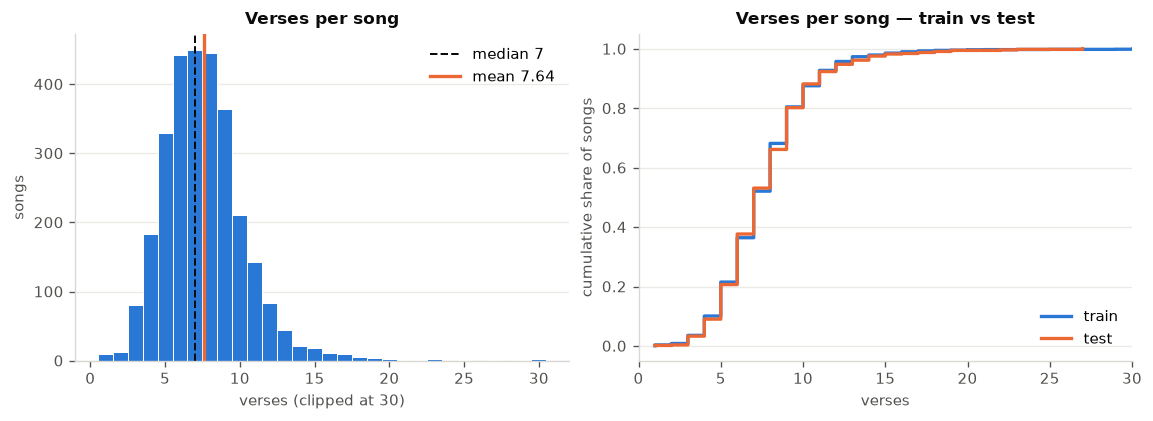

In [10]:
fig, (ax_hist, ax_ecdf) = plt.subplots(1, 2, figsize=(9.5, 3.4), constrained_layout=True)

counts = verses_per_song["n_verses"]
bins = np.arange(counts.min() - 0.5, min(counts.max(), 30) + 1.5, 1)
ax_hist.hist(counts.clip(upper=30), bins=bins, color=BLUE, edgecolor="white", linewidth=0.6)
ax_hist.axvline(counts.median(), color=INK, linewidth=1.2, linestyle="--",
                label=f"median {counts.median():.0f}")
ax_hist.axvline(counts.mean(), color=ORANGE, linewidth=2, label=f"mean {counts.mean():.2f}")
ax_hist.legend(loc="upper right")
ax_hist.set_title("Verses per song")
ax_hist.set_xlabel("verses (clipped at 30)")
ax_hist.set_ylabel("songs")
ax_hist.grid(axis="y")
ax_hist.set_axisbelow(True)

for name, color in [("train", BLUE), ("test", ORANGE)]:
    values = np.sort(verses_per_song.loc[verses_per_song["split"] == name, "n_verses"])
    ax_ecdf.step(values, np.arange(1, len(values) + 1) / len(values), where="post",
                 color=color, linewidth=2, label=name)
ax_ecdf.set_title("Verses per song — train vs test")
ax_ecdf.set_xlabel("verses")
ax_ecdf.set_ylabel("cumulative share of songs")
ax_ecdf.set_xlim(0, 30)
ax_ecdf.grid(axis="y")
ax_ecdf.set_axisbelow(True)
ax_ecdf.legend(loc="lower right")

plt.show()

## 5. Question 2 — how long is a verse?

Now that the verse text is in hand, each verse can simply be measured. One wrinkle first:
the text carries Genius-style structure markers on their own lines — `[Coro]`, `[Verso 1]`,
`[Letra de "…"]`. They are metadata about the verse, not words in it, so they are separated
out rather than counted as content.

In [11]:
HEADER = re.compile(r"\[[^\]]*\]")
WORD = re.compile(r"\w+", re.UNICODE)

def all_lines(text):
    return [line.strip() for line in str(text).split("\n") if line.strip()]

def is_header(line):
    return bool(HEADER.fullmatch(line))

verse_text["lines_all"] = verse_text["lyrics"].map(all_lines)
verse_text["lines_body"] = verse_text["lines_all"].map(lambda ls: [l for l in ls if not is_header(l)])

headers = [l for ls in verse_text["lines_all"] for l in ls if is_header(l)]
n_all = verse_text["lines_all"].str.len().sum()

print(f"structure-marker lines: {len(headers):,} of {n_all:,} non-empty lines ({len(headers) / n_all:.1%})")
print(f"verses carrying at least one: {verse_text['lines_all'].map(lambda ls: any(is_header(l) for l in ls)).sum():,} "
      f"({verse_text['lines_all'].map(lambda ls: any(is_header(l) for l in ls)).mean():.1%})")
print("\nMost common markers:")
print(pd.Series(headers).value_counts().head(10).to_string())

structure-marker lines: 5,305 of 153,191 non-empty lines (3.5%)
verses carrying at least one: 5,064 (23.0%)

Most common markers:
[Coro]          546
[Verso 1]       250
[Verso 2]       242
[Outro]         190
[Intro]         147
[Estribillo]    119
[Pre-Coro]      113
[Puente]        103
[Refrán]         65
[Verso 3]        64


In [12]:
verse_text["n_lines"] = verse_text["lines_body"].str.len()
verse_text["n_words"] = verse_text["lines_body"].map(lambda ls: sum(len(WORD.findall(l)) for l in ls))
verse_text["n_chars"] = verse_text["lines_body"].map(lambda ls: sum(len(l) for l in ls))
verse_text["n_lines_raw"] = verse_text["lines_all"].str.len()

empty = verse_text["n_lines"] == 0
print(f"verses with no content once markers are removed: {empty.sum()} ({empty.mean():.2%})")
print("examples:", verse_text.loc[empty, 'lyrics'].head(3).tolist())

verses with no content once markers are removed: 172 (0.78%)
examples: ['[Letra de "Noche De Travesura"]', '[Letra de "Rakata"]', '[Letra de "Inocente"]']


Those `172` verses are real annotation units — an annotator was shown them and labelled them —
but they hold no sung text (an instrumental interlude, a stray title marker). They are kept in
the main figures, since dropping them would misstate what the annotators actually worked
through, and the effect of excluding them is reported alongside.

### 5a. The distribution of verse length

In [13]:
measures = ["n_lines", "n_words", "n_chars"]
described = verse_text[measures].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(f"Verse length over all {len(verse_text):,} verses (structure markers excluded)\n")
print(described.to_string())

print("\nExcluding the content-empty verses:")
print(verse_text.loc[~empty, measures].agg(["count", "mean", "median"]).to_string())

print("\nWith structure markers counted as lines, for reference:")
print(f"  mean lines per verse: {verse_text['n_lines_raw'].mean():.2f} "
      f"(vs {verse_text['n_lines'].mean():.2f} content-only)")
print(f"\nwords per line: {verse_text['n_words'].sum() / verse_text['n_lines'].sum():.2f}")

Verse length over all 21,985 verses (structure markers excluded)

        n_lines   n_words   n_chars
count 21,985.00 21,985.00 21,985.00
mean       6.73     46.24    227.35
std        5.71     46.54    234.39
min        0.00      0.00      0.00
10%        2.00     13.00     64.00
25%        4.00     23.00    112.00
50%        6.00     36.00    176.00
75%        8.00     57.00    279.00
90%       12.00     88.00    435.00
max      291.00  2,359.00 11,887.00

Excluding the content-empty verses:
         n_lines   n_words   n_chars
count  21,813.00 21,813.00 21,813.00
mean        6.78     46.60    229.15
median      6.00     36.00    177.00

With structure markers counted as lines, for reference:
  mean lines per verse: 6.97 (vs 6.73 content-only)

words per line: 6.87


### 5b. Per verse vs per annotation

The question asks about verses, so the figures above weight every verse once. Because a verse
may carry three or four annotations, the *annotation*-weighted mean — what you would get by
reading straight down the raw file without deduplicating — is slightly different. Both are
reported so the gap is visible rather than hidden in a choice of `drop_duplicates`.

In [14]:
weighted = annotations[["verse_id"]].merge(
    verse_text[["verse_id"] + measures], on="verse_id", how="left"
)

comparison = pd.DataFrame({
    f"per verse (n={len(verse_text):,})": verse_text[measures].mean(),
    f"per annotation (n={len(weighted):,})": weighted[measures].mean(),
})
comparison["difference"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
comparison["relative"] = comparison["difference"] / comparison.iloc[:, 0]
print(comparison.to_string(formatters={"relative": "{:+.2%}".format}))

         per verse (n=21,985)  per annotation (n=84,464)  difference relative
n_lines                  6.73                       6.71       -0.02   -0.22%
n_words                 46.24                      46.01       -0.23   -0.51%
n_chars                227.35                     226.28       -1.07   -0.47%


### 5c. Verse length by split, language and label

In [15]:
def group_stats(column):
    grouped = verse_text.groupby(column)
    out = pd.DataFrame({
        "verses": grouped.size(),
        "lines (mean)": grouped["n_lines"].mean(),
        "lines (median)": grouped["n_lines"].median(),
        "words (mean)": grouped["n_words"].mean(),
        "words (median)": grouped["n_words"].median(),
        "chars (mean)": grouped["n_chars"].mean(),
        "words per line": grouped["n_words"].sum() / grouped["n_lines"].sum(),
    })
    return out

for column in ["split", "language", "is_misogynistic"]:
    print(f"\nBy {column}")
    print(group_stats(column).to_string())


By split
       verses  lines (mean)  lines (median)  words (mean)  words (median)  chars (mean)  words per line
split                                                                                                  
test     4425          6.55            5.00         44.90           36.00        220.18            6.85
train   17560          6.77            6.00         46.58           36.00        229.16            6.88

By language
          verses  lines (mean)  lines (median)  words (mean)  words (median)  chars (mean)  words per line
language                                                                                                  
es_ES      10541          7.15            6.00         50.33           40.00        247.64            7.04
es_LATAM   11444          6.34            5.00         42.47           33.00        208.67            6.70

By is_misogynistic
                 verses  lines (mean)  lines (median)  words (mean)  words (median)  chars (mean)  words per line

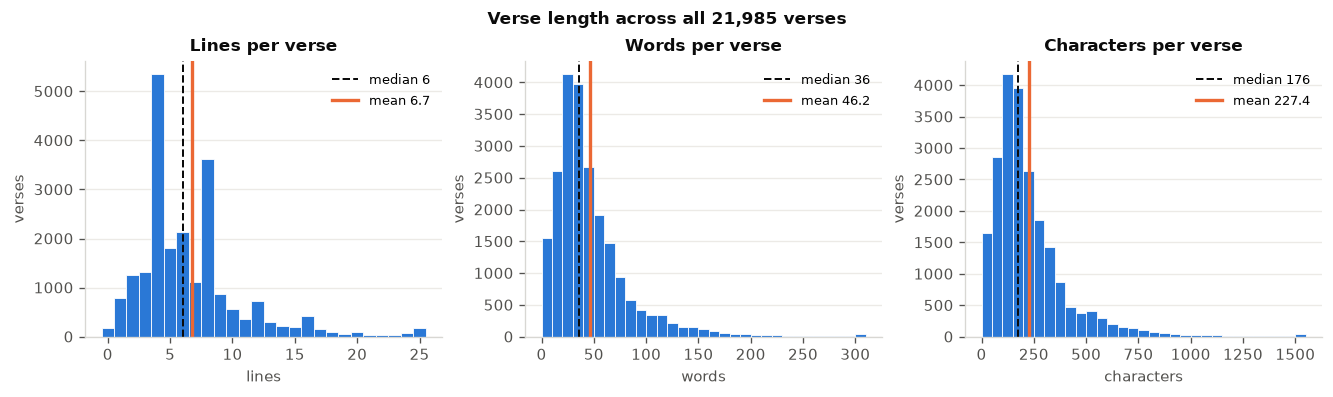

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), constrained_layout=True)

specs = [
    ("n_lines", "Lines per verse", np.arange(-0.5, 26.5, 1), "lines"),
    ("n_words", "Words per verse", np.arange(0, 320, 10), "words"),
    ("n_chars", "Characters per verse", np.arange(0, 1600, 50), "characters"),
]

for ax, (column, title, bins, xlabel) in zip(axes, specs):
    values = verse_text[column]
    ax.hist(values.clip(upper=bins[-1]), bins=bins, color=BLUE, edgecolor="white", linewidth=0.5)
    ax.axvline(values.median(), color=INK, linewidth=1.2, linestyle="--",
               label=f"median {values.median():.0f}")
    ax.axvline(values.mean(), color=ORANGE, linewidth=2, label=f"mean {values.mean():.1f}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("verses")
    ax.grid(axis="y")
    ax.set_axisbelow(True)

fig.suptitle(f"Verse length across all {len(verse_text):,} verses", fontsize=10,
             fontweight="bold", color=INK)
plt.show()

### 5d. Does verse length depend on position in the song?

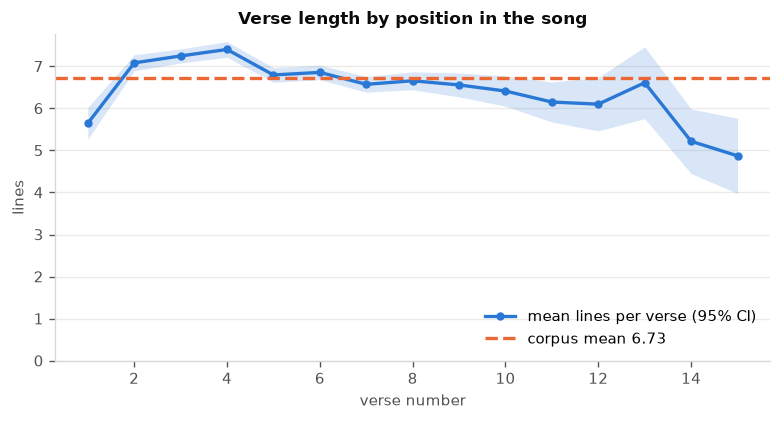

              verses  mean lines
verse_number                    
1               2878        5.64
2               2870        7.08
3               2858        7.25
4               2778        7.40
5               2595        6.79
6               2265        6.85
7               1823        6.57
8               1374        6.66
9                928        6.56
10               564        6.41
11               354        6.15
12               211        6.10
13               128        6.61
14                83        5.22
15                62        4.87


In [17]:
position = verse_text[verse_text["verse_number"] <= 15].groupby("verse_number")["n_lines"]
mean_by_position = position.mean()
sem_by_position = position.sem()
n_by_position = position.size()

fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
ax.fill_between(mean_by_position.index,
                mean_by_position - 1.96 * sem_by_position,
                mean_by_position + 1.96 * sem_by_position,
                color=BLUE, alpha=0.18, linewidth=0)
ax.plot(mean_by_position.index, mean_by_position, color=BLUE, linewidth=2, marker="o",
        markersize=4, label="mean lines per verse (95% CI)")
ax.axhline(verse_text["n_lines"].mean(), color=ORANGE, linewidth=2, linestyle="--",
           label=f"corpus mean {verse_text['n_lines'].mean():.2f}")
ax.set_title("Verse length by position in the song")
ax.set_xlabel("verse number")
ax.set_ylabel("lines")
ax.set_ylim(bottom=0)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.show()

print(pd.DataFrame({"verses": n_by_position, "mean lines": mean_by_position}).head(15).to_string())

### 5e. Validation against the song lyrics

An independent check: strip the structure markers from every verse of a song and the result
should reproduce the song's own `lyrics` field in `train.csv` / `test.csv`. Agreement on the
line totals means the verse segmentation really does partition the songs.

In [18]:
song_lines = songs.set_index("song_id")["lyrics"].map(lambda t: len(all_lines(t)))
verse_lines = verse_text.groupby("song_id")["n_lines"].sum()

total_song, total_verse = song_lines.sum(), verse_lines.sum()
print(f"non-empty lines in the song lyrics          : {total_song:,}")
print(f"content lines summed over the verse texts   : {total_verse:,}")
print(f"difference                                  : {total_verse - total_song:+,} "
      f"({abs(total_verse - total_song) / total_song:.4%})")

per_song_gap = (verse_lines - song_lines).abs()
print(f"\nsongs matching exactly: {(per_song_gap == 0).sum():,} / {len(per_song_gap):,} "
      f"({(per_song_gap == 0).mean():.1%})")
if (per_song_gap > 0).any():
    print(f"songs differing       : {(per_song_gap > 0).sum():,}  "
          f"(largest gap: {per_song_gap.max():.0f} lines)")

non-empty lines in the song lyrics          : 147,884
content lines summed over the verse texts   : 147,886
difference                                  : +2 (0.0014%)

songs matching exactly: 2,878 / 2,879 (100.0%)
songs differing       : 1  (largest gap: 2 lines)


## 6. Answers

In [19]:
vps = verses_per_song["n_verses"]

print("=" * 74)
print("Q1 — Average number of verses per song")
print("=" * 74)
print(f"  {vps.mean():.2f} verses per song   (median {vps.median():.0f}, SD {vps.std():.2f}, "
      f"IQR {vps.quantile(.25):.0f}–{vps.quantile(.75):.0f}, range {vps.min():.0f}–{vps.max():.0f})")
print(f"  over {len(vps):,} songs and {vps.sum():,} verses")
print()
print("=" * 74)
print("Q2 — Average length of a verse")
print("=" * 74)
print(f"  measured on the text of all {len(verse_text):,} verses, structure markers excluded")
print()
for column, unit in [("n_lines", "lines"), ("n_words", "words"), ("n_chars", "chars")]:
    s = verse_text[column]
    print(f"    {unit:<6} mean {s.mean():7.2f}   median {s.median():6.0f}   SD {s.std():7.2f}   "
          f"IQR {s.quantile(.25):.0f}–{s.quantile(.75):.0f}   range {s.min():.0f}–{s.max():.0f}")
print()
print(f"    words per line: {verse_text['n_words'].sum() / verse_text['n_lines'].sum():.2f}")
print()
print("  A typical verse is a short block of 6-7 lines and ~46 words, but the median")
print("  verse is shorter still (6 lines, 36 words): all three measures are strongly")
print("  right-skewed, with a long tail running out to a 291-line verse.")
print("=" * 74)

Q1 — Average number of verses per song
  7.64 verses per song   (median 7, SD 2.95, IQR 6–9, range 1–48)
  over 2,879 songs and 21,985 verses

Q2 — Average length of a verse
  measured on the text of all 21,985 verses, structure markers excluded

    lines  mean    6.73   median      6   SD    5.71   IQR 4–8   range 0–291
    words  mean   46.24   median     36   SD   46.54   IQR 23–57   range 0–2359
    chars  mean  227.35   median    176   SD  234.39   IQR 112–279   range 0–11887

    words per line: 6.87

  A typical verse is a short block of 6-7 lines and ~46 words, but the median
  verse is shorter still (6 lines, 36 words): all three measures are strongly
  right-skewed, with a long tail running out to a 291-line verse.


### Notes on how to read these numbers

- **Both answers are exact counts, not estimates.** Verses per song is a direct count of the
  verse inventory after the `train ∪ test` filter; verse length is measured on the verse text
  itself, now that `dataset_sin_pseudoetiquetado.csv` supplies it. Nothing here is
  reconstructed or extrapolated.
- **The unit is the verse, not the annotation.** The annotation file repeats each verse once
  per annotator (three or four times); §5b shows what changes if you weight by annotation
  instead — the means shift by well under a percent, so the choice is not load-bearing, but it
  is stated rather than assumed.
- **Structure markers are excluded from length.** Lines that are wholly `[Coro]`, `[Verso 2]`,
  `[Letra de "…"]` and the like are metadata, not content; they account for 3.3% of non-empty
  lines. §5a reports the marker-inclusive mean too, if you need the figure that matches a naive
  line count.
- **172 verses have no content after markers are removed** — instrumental interludes and stray
  title lines. They are kept in the headline figures because annotators did label them, which
  pulls the mean down slightly; §5a gives the marker-excluded comparison.
- **§5e is the reason to trust the segmentation.** Summing each song's verse lines reproduces
  its `lyrics` field almost exactly, which independently confirms that the verses partition the
  songs without overlap or loss.
- Character counts exclude line breaks and leading/trailing whitespace; words are Unicode
  `\w+` runs, so contractions such as *pa'* count as one token and elisions are not re-joined.